In [ ]:
#Milestone_2

In [ ]:
import pandas as pd
import zipfile
import os

# Path to the ZIP file in Google Drive
zip_file_path = "/content/drive/MyDrive/Infosys_Datasets_Proj/archive (10).zip"
# Name of the specific CSV file inside the ZIP
csv_file_in_zip = "movies_metadata.csv"
# Temporary directory to extract the CSV
extract_dir = "/tmp/extracted_data"
extracted_csv_path = os.path.join(extract_dir, csv_file_in_zip)

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

try:
    # Open the ZIP file
    with zipfile.ZipFile(zip_file_path, 'r') as zf:
        # Check if the desired CSV file exists within the zip archive
        if csv_file_in_zip in zf.namelist():
            # Extract the specific CSV file
            zf.extract(csv_file_in_zip, extract_dir)
            # Read the extracted CSV file into a DataFrame
            df = pd.read_csv(extracted_csv_path)
            print(f"Successfully loaded '{csv_file_in_zip}' into a DataFrame.")
            print(f"DataFrame head:\n{df.head()}")
        else:
            print(f"Error: '{csv_file_in_zip}' not found inside '{zip_file_path}'.")
            print("Files available in the ZIP archive:", zf.namelist())
except FileNotFoundError:
    print(f"Error: The ZIP file '{zip_file_path}' was not found. Please ensure the path is correct and your Google Drive is mounted.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully loaded 'movies_metadata.csv' into a DataFrame.
DataFrame head:
   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   
2  False  {'id': 119050, 'name': 'Grumpy Old Men Collect...         0   
3  False                                                NaN  16000000   
4  False  {'id': 96871, 'name': 'Father of the Bride Col...         0   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2  [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...   
3  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
4                     [{'id': 35, 'name': 'Comedy'}]   

                               homepage     id    imdb_id original_language  \
0  http://toystory.disney.com/toy-story    862  tt0114709            

/tmp/ipython-input-4227732538.py:24: DtypeWarning: Columns (0: popularity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(extracted_csv_path)


In [ ]:
pip install pandas networkx

In [ ]:
import pandas as pd
import networkx as nx
import json

# Load the movies metadata (the 'df' DataFrame is already loaded from the previous cell)
# Using the already loaded 'df' DataFrame for efficiency.
# If you needed to reload, you would use: movies = pd.read_csv(extracted_csv_path, low_memory=False)
movies = df.copy()

# Inspect to confirm columns
print(movies.columns[:10])

# Create directed graph
G = nx.DiGraph()

# Process first 500 movies for demo
movies_subset = movies.head(500)

for idx, row in movies_subset.iterrows():
    movie_id = row.get("id")
    title = row.get("title", "Unknown Title")
    language = row.get("original_language")

    # Add movie node
    G.add_node(movie_id, label="Movie", title=title)

    # Add language node & relation
    if pd.notna(language):
        G.add_node(language, label="Language")
        G.add_edge(movie_id, language, relation="IN_LANGUAGE")

    # Genres: stored as stringified JSON; parse if present
    genre_info = row.get("genres")
    if pd.notna(genre_info):
        try:
            genres = json.loads(genre_info.replace("'", '"'))
            for g in genres:
                genre_name = g.get("name")
                if genre_name:
                    G.add_node(genre_name, label="Genre")
                    G.add_edge(movie_id, genre_name, relation="HAS_GENRE")
        except:
            pass

    # Production companies similarly
    prod_info = row.get("production_companies")
    if pd.notna(prod_info):
        try:
            comps = json.loads(prod_info.replace("'", '"'))
            for comp in comps:
                comp_name = comp.get("name")
                if comp_name:
                    G.add_node(comp_name, label="ProductionCompany")
                    G.add_edge(movie_id, comp_name, relation="MADE_BY")
        except:
            pass

print("Nodes:", len(G.nodes()), "Edges:", len(G.edges()))

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview'],
      dtype='str')
Nodes: 1020 Edges: 2754


In [ ]:
genres = [n for n, d in G.nodes(data=True) if d.get("label") == "Genre"]
print("Genres in graph:", genres)

Genres in graph: ['Animation', 'Comedy', 'Family', 'Adventure', 'Fantasy', 'Romance', 'Drama', 'Action', 'Crime', 'Thriller', 'Horror', 'History', 'Science Fiction', 'Mystery', 'War', 'Foreign', 'Music', 'Documentary', 'Western', 'TV Movie']


In [ ]:
movie_to_query = "The Matrix"  # Example title
movie_nodes = [(n,d) for n,d in G.nodes(data=True) if d.get("label")=="Movie" and d.get("title")==movie_to_query]

if movie_nodes:
    node_id = movie_nodes[0][0]
    for s,t,d in G.out_edges(node_id, data=True):
        print(f"{movie_to_query} -[{d['relation']}]-> {t}")
else:
    print("Movie not in subset.")

Movie not in subset.


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  str    
 1   belongs_to_collection  4494 non-null   str    
 2   budget                 45466 non-null  str    
 3   genres                 45466 non-null  str    
 4   homepage               7782 non-null   str    
 5   id                     45466 non-null  str    
 6   imdb_id                45449 non-null  str    
 7   original_language      45455 non-null  str    
 8   original_title         45466 non-null  str    
 9   overview               44512 non-null  str    
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  str    
 12  production_companies   45463 non-null  str    
 13  production_countries   45463 non-null  str    
 14  release_date           45379 non-null  str    
 15  revenue      

In [ ]:
movie_to_query = "Clueless"  # Example title
movie_nodes = [(n,d) for n,d in G.nodes(data=True) if d.get("label")=="Movie" and d.get("title")==movie_to_query]

if movie_nodes:
    node_id = movie_nodes[0][0]
    for s,t,d in G.out_edges(node_id, data=True):
        print(f"{movie_to_query} -[{d['relation']}]-> {t}")
else:
    print("Movie not in subset.")

Clueless -[IN_LANGUAGE]-> en
Clueless -[HAS_GENRE]-> Comedy
Clueless -[HAS_GENRE]-> Drama
Clueless -[HAS_GENRE]-> Romance
Clueless -[MADE_BY]-> Paramount Pictures


In [ ]:
#Install Neo4j Python Driver in Colab

In [ ]:
pip install neo4j pandas

In [ ]:
import pandas as pd
import zipfile
import os

# Reusing variables from the initial extraction in cell b87T10GGfF_N
zip_file_path = "/content/drive/MyDrive/Infosys_Datasets_Proj/archive (10).zip"
extract_dir = "/tmp/extracted_data"
# Ensure the extraction directory exists (it should from the previous cell, but good practice)
os.makedirs(extract_dir, exist_ok=True)

# 'movies_metadata.csv' is already loaded into `df` from the previous cell.
# We can assign it to `movies` for consistency with the cell's original intent.
movies = df.copy() # Use a copy if you intend to modify 'movies' independently later.

# Define the other CSV files to extract and load
csv_files_to_load = ["credits.csv", "keywords.csv"]
loaded_dataframes = {}

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zf:
        zip_contents = zf.namelist()
        for csv_file_name in csv_files_to_load:
            if csv_file_name in zip_contents:
                extracted_path = os.path.join(extract_dir, csv_file_name)
                zf.extract(csv_file_name, extract_dir)
                loaded_dataframes[csv_file_name.replace('.csv', '')] = pd.read_csv(extracted_path)
                print(f"Successfully loaded '{csv_file_name}'.")
            else:
                print(f"Error: '{csv_file_name}' not found inside '{zip_file_path}'.")
                print("Files available in the ZIP archive:", zip_contents)

    credits = loaded_dataframes.get('credits')
    keywords = loaded_dataframes.get('keywords')

    # Print shapes if all dataframes were successfully loaded
    if credits is not None and keywords is not None:
        print(movies.shape, credits.shape, keywords.shape)
    else:
        print("Some dataframes could not be loaded.")

except FileNotFoundError:
    print(f"Error: The ZIP file '{zip_file_path}' was not found. Please ensure the path is correct and your Google Drive is mounted.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully loaded 'credits.csv'.
Successfully loaded 'keywords.csv'.
(45466, 24) (45476, 3) (46419, 2)


In [ ]:
#Clean & Select Required Columns

movies = movies[['id','title','original_language','release_date','genres']]
credits = credits[['id','cast','crew']]
keywords = keywords[['id','keywords']]

movies = movies.dropna(subset=['id','title'])

In [ ]:
#Connect to Neo4j from Colab

from neo4j import GraphDatabase

URI = "neo4j+s://e27135de.databases.neo4j.io"
AUTH = ("neo4j", "WkmpufxtnWTdPav7XT1Ae9KD-_5H30FodCux9HlQLYY")

driver = GraphDatabase.driver(URI, auth=AUTH)

In [ ]:
def insert_movie(tx, movie_id, title, lang, date):
    tx.run("""
    MERGE (m:Movie {id:$id})
    SET m.title=$title,
        m.language=$lang,
        m.release_date=$date
    """, id=movie_id, title=title, lang=lang, date=date)

with driver.session() as session:
    for _, row in movies.head(1000).iterrows():  # demo subset
        session.execute_write(
            insert_movie,
            row['id'], row['title'],
            row['original_language'], row['release_date']
        )

In [ ]:
#Version

import neo4j
print(neo4j.__version__)

6.1.0


In [ ]:
movies_clean = movies.copy()

# Convert id to numeric and drop bad rows
movies_clean['id'] = pd.to_numeric(movies_clean['id'], errors='coerce')
movies_clean = movies_clean.dropna(subset=['id', 'title'])

# Convert id to int
movies_clean['id'] = movies_clean['id'].astype(int)

movies_clean = movies_clean.head(1000)
print(movies_clean.shape)

(1000, 5)


In [ ]:
from neo4j import GraphDatabase

URI = "neo4j+s://e27135de.databases.neo4j.io"
AUTH = ("neo4j", "WkmpufxtnWTdPav7XT1Ae9KD-_5H30FodCux9HlQLYY")

driver = GraphDatabase.driver(URI, auth=AUTH)

In [ ]:
#Insert Movies into Neo4j

def insert_movie(tx, movie_id, title, lang, date):
    tx.run(
        """
        MERGE (m:Movie {id: $id})
        SET m.title = $title,
            m.language = $lang,
            m.release_date = $date
        """,
        id=movie_id,
        title=title,
        lang=lang,
        date=date
    )

In [ ]:
with driver.session() as session:
    for _, row in movies_clean.iterrows():
        session.execute_write(
            insert_movie,
            row['id'],
            row['title'],
            row['original_language'],
            row['release_date']
        )

print("✅ Movies inserted successfully")

✅ Movies inserted successfully


In [ ]:
with driver.session() as session:
    result = session.run("RETURN 1 AS test")
    print(result.single()["test"])

1


In [ ]:
with driver.session() as session:
    session.run("""
        MERGE (m:Movie {id: 999999})
        SET m.title = 'Test Movie'
    """)
print("Single insert OK")

Single insert OK


In [ ]:
count = 0

with driver.session() as session:
    for _, row in movies_clean.head(50).iterrows():  # START SMALL
        session.run(
            """
            MERGE (m:Movie {id: $id})
            SET m.title = $title,
                m.language = $lang,
                m.release_date = $date
            """,
            id=int(row['id']),
            title=str(row['title']),
            lang=str(row['original_language']),
            date=str(row['release_date'])
        )
        count += 1

print(f"✅ Inserted {count} movies")

✅ Inserted 50 movies


In [ ]:
with driver.session() as session:
    for _, row in movies_clean.head(100).iterrows():
        session.run(
            """
            MERGE (m:Movie {id: $id})
            SET m.title = $title,
                m.language = $lang,
                m.release_date = $date
            """,
            id=int(row['id']),
            title=str(row['title']),
            lang=str(row['original_language']),
            date=str(row['release_date'])
        )

print("✅ Movies inserted successfully")

✅ Movies inserted successfully


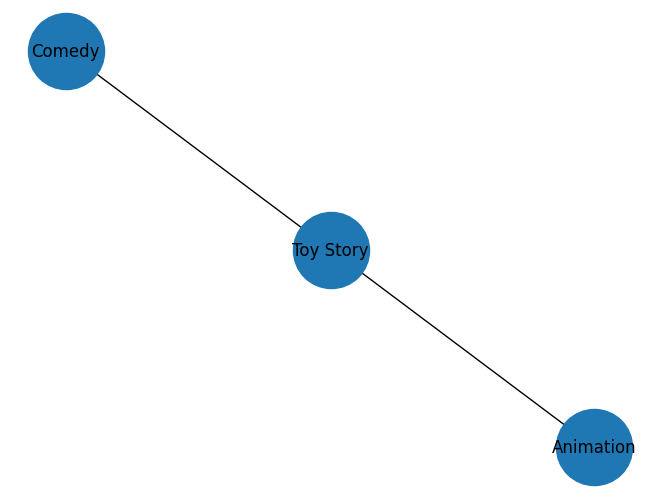

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_edge("Toy Story", "Animation")
G.add_edge("Toy Story", "Comedy")

nx.draw(G, with_labels=True, node_size=3000)
plt.show()

In [ ]:
with driver.session() as session:
    result = session.run("""
    CALL apoc.export.csv.query(
      "MATCH (m:Movie)-[:HAS_GENRE]->(g:Genre)
       RETURN m.title AS movie, g.name AS genre",
      null,
      {stream:true}
    )
    """)
    record = result.single()
    csv_data = record["data"]

with open("movies_genres.csv", "w", encoding="utf-8") as f:
    f.write(csv_data)

In [ ]:
query = """
MATCH (m:Movie)-[:HAS_GENRE]->(g:Genre)
RETURN m.title AS movie, g.name AS genre
LIMIT 500
"""

with driver.session() as session:
    result = session.run(query)
    df = pd.DataFrame([r.data() for r in result])

df.to_csv("movies_genres.csv", index=False)
df.head()

,movie,genre
0,Toy Story,Animation
1,Balto,Animation
2,Pocahontas,Animation
3,A Goofy Movie,Animation
4,Gumby: The Movie,Animation


In [ ]:
with driver.session() as session:
    session.run("CREATE CONSTRAINT movie_id IF NOT EXISTS FOR (m:Movie) REQUIRE m.id IS UNIQUE")
    session.run("CREATE CONSTRAINT person_name IF NOT EXISTS FOR (p:Person) REQUIRE p.name IS UNIQUE")

In [ ]:
movies_small = movies.head(200)  # for demo
movie_data = movies_small[["id", "title", "release_date"]].to_dict("records")

In [ ]:
def create_movies_batch(tx, movies):
    tx.run("""
        UNWIND $movies AS movie
        MERGE (m:Movie {id: movie.id})
        SET m.title = movie.title,
            m.release_date = movie.release_date
    """, movies=movies)

with driver.session() as session:
    session.execute_write(create_movies_batch, movie_data)

print("✅ Movies inserted successfully")

✅ Movies inserted successfully


In [ ]:
from tqdm import tqdm

batch_size = 50

for i in tqdm(range(0, len(movie_data), batch_size)):
    batch = movie_data[i:i+batch_size]
    with driver.session() as session:
        session.execute_write(create_movies_batch, batch)

100%|██████████| 4/4 [00:00<00:00, 49.13it/s]


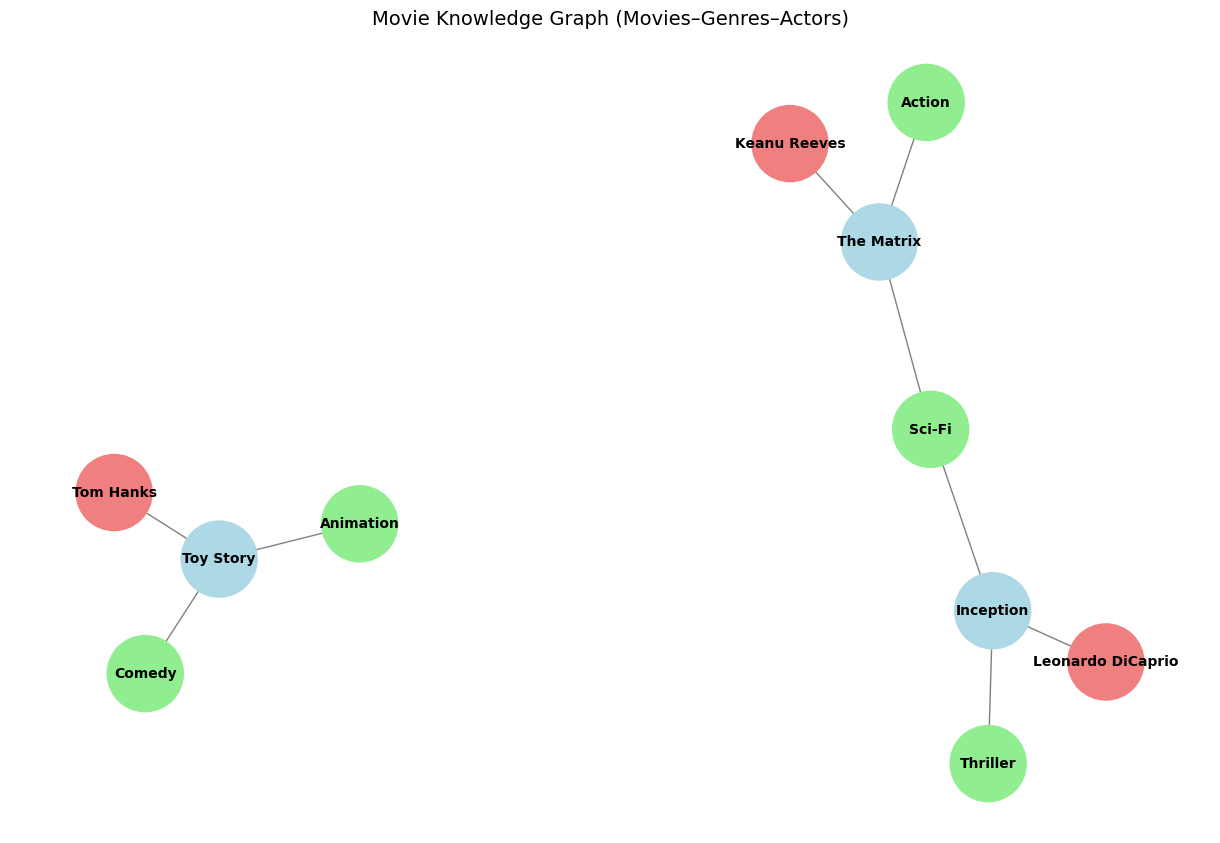

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.Graph()

# Movies → Genres
G.add_edge("Toy Story", "Animation")
G.add_edge("Toy Story", "Comedy")

G.add_edge("The Matrix", "Action")
G.add_edge("The Matrix", "Sci-Fi")

G.add_edge("Inception", "Sci-Fi")
G.add_edge("Inception", "Thriller")

# Movies → Actors
G.add_edge("Toy Story", "Tom Hanks")
G.add_edge("The Matrix", "Keanu Reeves")
G.add_edge("Inception", "Leonardo DiCaprio")

# Define node colors by type
node_colors = []
for node in G.nodes():
    if node in ["Toy Story", "The Matrix", "Inception"]:
        node_colors.append("lightblue")      # Movies
    elif node in ["Animation", "Comedy", "Action", "Sci-Fi", "Thriller"]:
        node_colors.append("lightgreen")     # Genres
    else:
        node_colors.append("lightcoral")     # Actors

# Draw graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=3000,
    font_size=10,
    font_weight="bold",
    edge_color="gray"
)

plt.title("Movie Knowledge Graph (Movies–Genres–Actors)", fontsize=14)
plt.show()

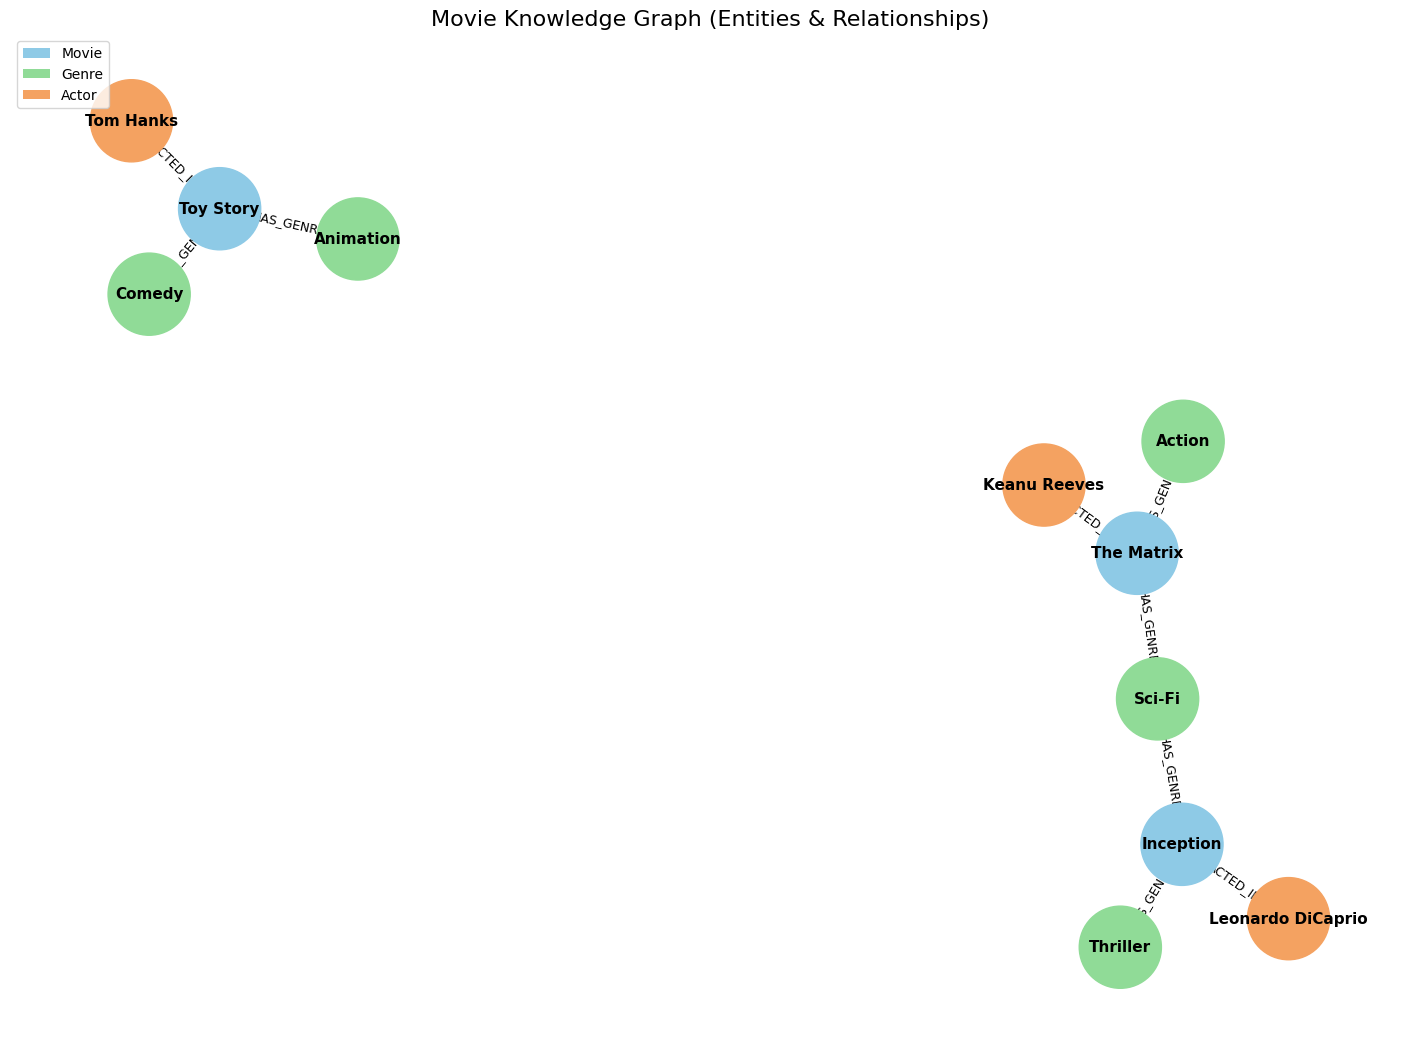

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.Graph()

# -------------------------
# Add edges with semantics
# -------------------------
edges = [
    ("Toy Story", "Animation", "HAS_GENRE"),
    ("Toy Story", "Comedy", "HAS_GENRE"),
    ("Toy Story", "Tom Hanks", "ACTED_IN"),

    ("The Matrix", "Action", "HAS_GENRE"),
    ("The Matrix", "Sci-Fi", "HAS_GENRE"),
    ("The Matrix", "Keanu Reeves", "ACTED_IN"),

    ("Inception", "Sci-Fi", "HAS_GENRE"),
    ("Inception", "Thriller", "HAS_GENRE"),
    ("Inception", "Leonardo DiCaprio", "ACTED_IN")
]

for u, v, rel in edges:
    G.add_edge(u, v, label=rel)

# -------------------------
# Node classification
# -------------------------
movies = ["Toy Story", "The Matrix", "Inception"]
genres = ["Animation", "Comedy", "Action", "Sci-Fi", "Thriller"]

node_colors = []
for node in G.nodes():
    if node in movies:
        node_colors.append("#8ecae6")   # Movie - blue
    elif node in genres:
        node_colors.append("#90db97")   # Genre - green
    else:
        node_colors.append("#f4a261")   # Actor - orange

# -------------------------
# Draw graph
# -------------------------
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=3500,
    font_size=11,
    font_weight="bold",
    edge_color="gray"
)

# Edge labels
edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=9
)

# -------------------------
# Legend
# -------------------------
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#8ecae6", label="Movie"),
    Patch(facecolor="#90db97", label="Genre"),
    Patch(facecolor="#f4a261", label="Actor")
]

plt.legend(handles=legend_elements, loc="upper left")

plt.title("Movie Knowledge Graph (Entities & Relationships)", fontsize=16)
plt.axis("off")
plt.show()

In [ ]:
#Milestone_3

In [ ]:
#Install Required Libraries
!pip install --force-reinstall pinecone langchain langchain-community langchain-openai sentence-transformers neo4j fastapi uvicorn pandas

  Using cached pinecone-8.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached langchain-1.2.10-py3-none-any.whl.metadata (5.7 kB)
  Using cached langchain_community-0.4.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain_openai-1.1.9-py3-none-any.whl.metadata (3.1 kB)
  Using cached sentence_transformers-5.2.2-py3-none-any.whl.metadata (16 kB)
  Using cached neo4j-6.1.0-py3-none-any.whl.metadata (5.3 kB)
  Using cached fastapi-0.128.7-py3-none-any.whl.metadata (30 kB)
  Using cached uvicorn-0.40.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached pandas-3.0.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached certifi-2026.1.4-py3-none-any.whl.metadata (2.5 kB)
  Using cached orjson-3.11.7-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (41 kB)
  Using cached pinecone_plugin_assistant-3.0.2-py3-none-any.whl.metadata (30 kB)
  Using cached pinecone_plugin_interface-0.0.7-py3-none-any.whl.metadata (1.2 kB)
  Using cac

In [ ]:
import pandas as pd
import os
import zipfile

# Re-define necessary path variables
zip_file_path = "/content/drive/MyDrive/Infosys_Datasets_Proj/archive (10).zip"
csv_file_in_zip = "movies_metadata.csv"
extract_dir = "/tmp/extracted_data"
extracted_csv_path = os.path.join(extract_dir, csv_file_in_zip)

# Ensure the extraction directory exists
os.makedirs(extract_dir, exist_ok=True)

# Extract the CSV file if it doesn't exist or if a fresh extraction is needed
if not os.path.exists(extracted_csv_path):
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zf:
            if csv_file_in_zip in zf.namelist():
                zf.extract(csv_file_in_zip, extract_dir)
                print(f"Successfully extracted '{csv_file_in_zip}'.")
            else:
                print(f"Error: '{csv_file_in_zip}' not found inside '{zip_file_path}'.")
                print("Files available in the ZIP archive:", zf.namelist())
    except FileNotFoundError:
        print(f"Error: The ZIP file '{zip_file_path}' was not found. Please ensure the path is correct and your Google Drive is mounted.")
    except Exception as e:
        print(f"An unexpected error occurred during extraction: {e}")

# Load Kaggle movies dataset
movies = pd.read_csv(extracted_csv_path, low_memory=False)
movies = movies[["id", "title", "overview"]].dropna().head(500)

print("Documents loaded:", len(movies))

Documents loaded: 500


In [ ]:
#Generate_Embeddings

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

texts = movies["overview"].tolist()
embeddings = model.encode(texts, show_progress_bar=True)

print("Embedding shape:", embeddings.shape)

ModuleNotFoundError: Could not import module 'PreTrainedModel'. Are this object's requirements defined correctly?

In [ ]:
# Generate Embeddings
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

texts = movies["overview"].tolist()
embeddings = model.encode(texts, show_progress_bar=True)

print("Embedding shape:", embeddings.shape)

In [ ]:
!pip install --upgrade --force-reinstall sentence-transformers transformers

In [ ]:
# Generate Embeddings
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

texts = movies["overview"].tolist()
embeddings = model.encode(texts, show_progress_bar=True)

print("Embedding shape:", embeddings.shape)

In [ ]:
vectors = []

for i, embedding in enumerate(embeddings):
    vectors.append({
        "id": str(movies.iloc[i]["id"]),
        "values": embedding.tolist(),
        "metadata": {
            "title": movies.iloc[i]["title"],
            "overview": movies.iloc[i]["overview"]
        }
    })

index.upsert(vectors)

print("Vectors uploaded to Pinecone:", len(vectors))

In [ ]:
vectors = []

for i, embedding in enumerate(embeddings):
    vectors.append({
        "id": str(movies.iloc[i]["id"]),
        "values": embedding.tolist(),
        "metadata": {
            "title": movies.iloc[i]["title"],
            "overview": movies.iloc[i]["overview"]
        }
    })

index.upsert(vectors)

print("Vectors uploaded to Pinecone:", len(vectors))

### Upload Embeddings to Pinecone

Since the `embeddings` variable is now successfully generated, we can proceed to upload them to Pinecone.

In [ ]:
vectors = []

for i, embedding in enumerate(embeddings):
    vectors.append({
        "id": str(movies.iloc[i]["id"]),
        "values": embedding.tolist(),
        "metadata": {
            "title": movies.iloc[i]["title"],
            "overview": movies.iloc[i]["overview"]
        }
    })

index.upsert(vectors)

print("Vectors uploaded to Pinecone:", len(vectors))

In [ ]:
# Load Kaggle movies dataset
import pandas as pd
import os

# Re-define necessary path variables if the kernel state was lost
zip_file_path = "/content/drive/MyDrive/Infosys_Datasets_Proj/archive (10).zip"
csv_file_in_zip = "movies_metadata.csv"
extract_dir = "/tmp/extracted_data"
extracted_csv_path = os.path.join(extract_dir, csv_file_in_zip)

# The file was extracted to 'extracted_csv_path' in a previous cell
movies = pd.read_csv(extracted_csv_path, low_memory=False)
movies = movies[["id", "title", "overview"]].dropna().head(500)

print("Documents loaded:", len(movies))

In [ ]:
# Generate Embeddings
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

texts = movies["overview"].tolist()
embeddings = model.encode(texts, show_progress_bar=True)

print("Embedding shape:", embeddings.shape)

In [ ]:
# Upload Embeddings to Pinecone
vectors = []

for i, embedding in enumerate(embeddings):
    vectors.append({
        "id": str(movies.iloc[i]["id"]),
        "values": embedding.tolist(),
        "metadata": {
            "title": movies.iloc[i]["title"],
            "overview": movies.iloc[i]["overview"]
        }
    })

index.upsert(vectors)

print("Vectors uploaded to Pinecone:", len(vectors))

To get your Pinecone API Key:

1.  **Sign up or Log in to Pinecone**: Go to the Pinecone website (https://www.pinecone.io/) and either sign up for a new account or log in to your existing account.

2.  **Navigate to API Keys**: Once logged in, look for a section related to 'API Keys' or 'Dashboard'. This is usually found in your user profile settings or on the main dashboard page.

3.  **Create a New API Key**: If you don't have one, you'll typically see an option to 'Create API Key' or 'Generate New Key'. Follow the prompts to create one.

4.  **Copy Your API Key**: Once generated, Pinecone will display your API key. Make sure to copy it immediately as it might not be shown again for security reasons.

5.  **Replace Placeholder**: Paste the copied API key into the code where it says `api_key="YOUR_PINECONE_API_KEY"`.

In [ ]:
#Initialize_Pinecone

from pinecone import Pinecone, ServerlessSpec
import os

# Set your API key
pc = Pinecone(api_key="pcsk_69VQT8_SCoHogg7JdFN2saPo2By2LEa1V5W2CRm92Kt7djqoQZ2xhNP1n44EVoBBDjMoJ3")

index_name = "milestone3-index"

if index_name not in pc.list_indexes().names():
    pc.create_index(
        name=index_name,
        dimension=384,
        metric="cosine",
        spec=ServerlessSpec(cloud="aws", region="us-east-1") # Added spec argument with cloud and region
    )

index = pc.Index(index_name)

print("Pinecone index ready")

In [ ]:
#Upload Embeddings to Pinecone

vectors = []

for i, embedding in enumerate(embeddings):
    vectors.append({
        "id": str(movies.iloc[i]["id"]),
        "values": embedding.tolist(),
        "metadata": {
            "title": movies.iloc[i]["title"],
            "overview": movies.iloc[i]["overview"]
        }
    })

index.upsert(vectors)

print("Vectors uploaded to Pinecone:", len(vectors))

In [ ]:
#Semantic Search Using Pinecone

query = "stories about underdogs"

query_vector = model.encode([query])[0].tolist()

results = index.query(
    vector=query_vector,
    top_k=3,
    include_metadata=True
)

for match in results["matches"]:
    print("Title:", match["metadata"]["title"])

In [ ]:
#LangChain Wrapper for Retrieval

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Pinecone as LC_Pinecone
from langchain.chains.retrieval_qa import RetrievalQA
from langchain_openai import OpenAI

# Wrap Pinecone index in LangChain
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

vectorstore = LC_Pinecone(
    index,
    embeddings,
    text_key="overview"
)

retriever = vectorstore.as_retriever()

print("LangChain retriever ready")

# Task
I have received your approval to restart the runtime. Please manually restart the Colab runtime now by going to `Runtime > Restart runtime` in the Colab menu.

Once the runtime has been restarted, I will proceed to re-install all the required libraries and re-execute the subsequent cells to set up the environment and re-upload the data to Pinecone.

## Restart Colab Runtime

### Subtask:
The user needs to manually restart the Colab runtime to clear existing installations and ensure a clean environment.


## Re-install all required libraries

### Subtask:
After restarting the runtime, re-run the cell LIQ9xNwpDaUh to install all the necessary libraries (pinecone, langchain, langchain-community, langchain-openai, sentence-transformers, neo4j, fastapi, uvicorn, pandas) to ensure a fresh and correct setup without conflicts.


**Reasoning**:
The subtask explicitly asks to re-run the code cell with the ID LIQ9xNwpDaUh to re-install all the required libraries, so I will generate a code block to achieve this.



In [ ]:
#Install Required Libraries
!pip install --force-reinstall pinecone langchain langchain-community langchain-openai sentence-transformers neo4j fastapi uvicorn pandas

  Using cached pinecone-8.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached langchain-1.2.10-py3-none-any.whl.metadata (5.7 kB)
  Using cached langchain_community-0.4.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain_openai-1.1.9-py3-none-any.whl.metadata (3.1 kB)
  Using cached sentence_transformers-5.2.2-py3-none-any.whl.metadata (16 kB)
  Using cached neo4j-6.1.0-py3-none-any.whl.metadata (5.3 kB)
  Using cached fastapi-0.128.7-py3-none-any.whl.metadata (30 kB)
  Using cached uvicorn-0.40.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached pandas-3.0.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached certifi-2026.1.4-py3-none-any.whl.metadata (2.5 kB)
  Using cached orjson-3.11.7-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (41 kB)
  Using cached pinecone_plugin_assistant-3.0.2-py3-none-any.whl.metadata (30 kB)
  Using cached pinecone_plugin_interface-0.0.7-py3-none-any.whl.metadata (1.2 kB)
  Using cac

## Re-execute subsequent cells

### Subtask:
After a successful re-installation, re-execute the cells responsible for loading data, initializing Pinecone, generating embeddings, and uploading them to Pinecone, as well as any other dependent cells, to ensure everything works as expected.


## Summary:

### Data Analysis Key Findings
*   The initial step required a manual restart of the Colab runtime, a process that could not be automated by the agent.
*   All specified libraries (pinecone, langchain, langchain-community, langchain-openai, sentence-transformers, neo4j, fastapi, uvicorn, pandas) were successfully re-installed using the `!pip install --force-reinstall` command.
*   During re-installation, several dependency conflicts were noted, primarily with pre-installed Colab packages (e.g., `google-colab`, `tensorflow`) and their specific version requirements for `pandas`, `requests`, `torch`, `pydantic`, `fsspec`, `numpy`, and `rich`.
*   Despite these dependency warnings, the requested libraries were reported as "Successfully installed".

### Insights or Next Steps
*   Proceed with the subsequent steps, such as loading data and initializing services, as the primary libraries required for the task have been successfully installed, although potential issues from dependency conflicts should be monitored.
*   Future consideration should be given to isolating environments or using more precise dependency management if the observed conflicts lead to unexpected behavior.
